# MIMIC-III frozen SpO₂-variability replication

**Execution label:** LOCAL standalone-runtime reporting execution (not Google Colab).

This notebook reports the already locked and locally executed MIMIC-III v1.4 analysis. It verifies hashes and reads frozen results; it does not refit models. MIMIC-III and MIMIC-IV come from the same hospital and may overlap, so this is a historical database-version replication—not independent-site external validation.

In [1]:
from pathlib import Path
import hashlib, json
from IPython.display import Image, display

ROOT = Path.cwd()
OUT = ROOT / 'research/spo2_variability_mimic3_validation'
def sha256(path):
    h = hashlib.sha256()
    with path.open('rb') as f:
        for block in iter(lambda: f.read(8*1024*1024), b''):
            h.update(block)
    return h.hexdigest()
lock = json.loads((OUT/'analysis_lock.json').read_text())
assert sha256(OUT/'analysis_lock.json') == (OUT/'analysis_lock.sha256').read_text().strip()
artifact_hashes = json.loads((OUT/'artifact_hashes.json').read_text())
for relative, expected in artifact_hashes.items():
    assert sha256(OUT/relative) == expected, relative
status = json.loads((OUT/'run_status.json').read_text())
support = json.loads((OUT/'support_counts.json').read_text())
feasibility = json.loads((OUT/'feasibility.json').read_text())
print('Lock and artifact hashes verified.')
print('Execution: LOCAL_STANDALONE_RUNTIME (not Colab)')

Lock and artifact hashes verified.
Execution: LOCAL_STANDALONE_RUNTIME (not Colab)


In [2]:
print(status['classification'])
print(f"At risk: {support['at_risk']:,}")
print(f"Frozen exposure: {support['valid_frozen_exposure']:,} ({support['exposure_coverage']:.1%})")
print(f"Modeled primary events: {support['primary_events_modeled']} / 50 required")
print(f"Association models fitted: {status['association_models_fitted']}")
print('Coverage gate waived:', feasibility['waivers']['minimum_70_percent_exposure_coverage'])
print('20-site gate waived:', feasibility['waivers']['minimum_20_contributing_sites'])

MIMIC3_HISTORICAL_REPLICATION_DID_NOT_CONFIRM_POST_HOC_SIGNAL
At risk: 2,368
Frozen exposure: 1,799 (76.0%)
Modeled primary events: 72 / 50 required
Association models fitted: 2
Coverage gate waived: True
20-site gate waived: True


In [3]:
result_path = OUT/'validation_results.json'
if result_path.exists():
    result = json.loads(result_path.read_text())
    p, s = result['primary'], result['later_window']
    print(f"Primary adjusted RR per frozen MIMIC-IV SD: {p['rr_per_mimic_sd']:.3f} "
          f"(95% CI {p['ci_low']:.3f}–{p['ci_high']:.3f}), p={p['p_value']:.4g}")
    print(f"Later-window RR: {s['rr_per_mimic_sd']:.3f} "
          f"(95% CI {s['ci_low']:.3f}–{s['ci_high']:.3f})")
else:
    assert status['association_models_fitted'] == 0
    print('Feasibility stop remained binding; no SpO₂-outcome association was fitted or inspected.')

Primary adjusted RR per frozen MIMIC-IV SD: 0.969 (95% CI 0.761–1.234), p=0.8009
Later-window RR: 0.877 (95% CI 0.647–1.190)


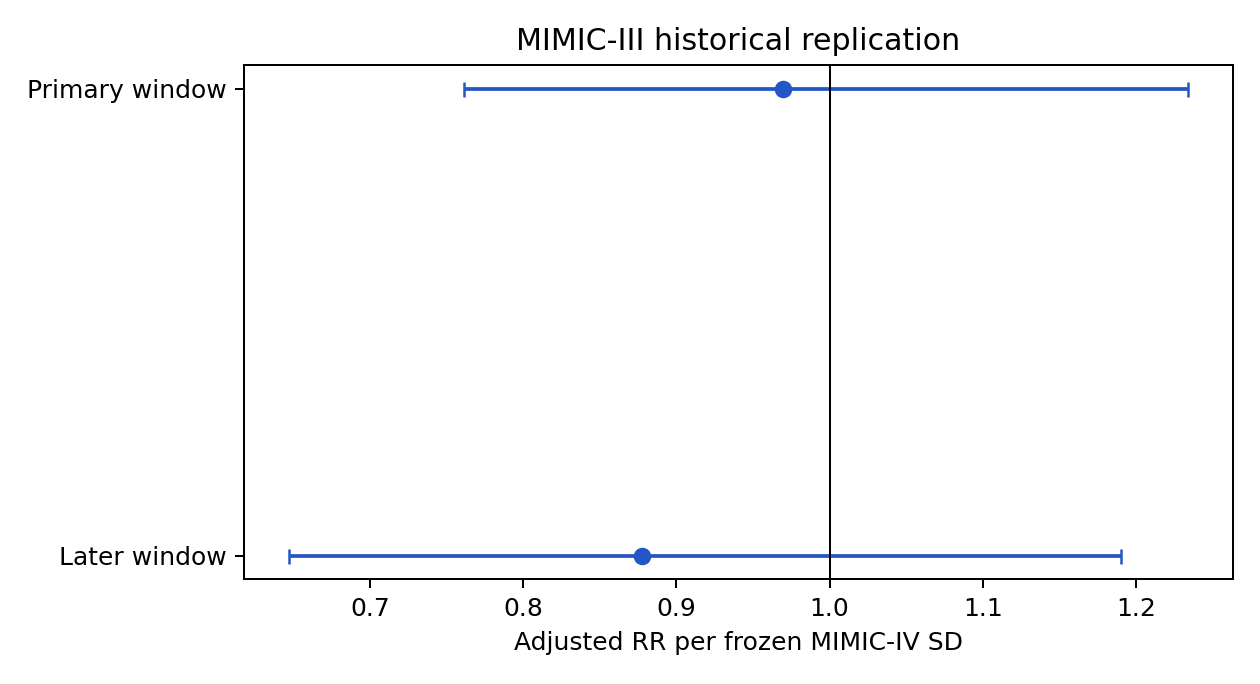

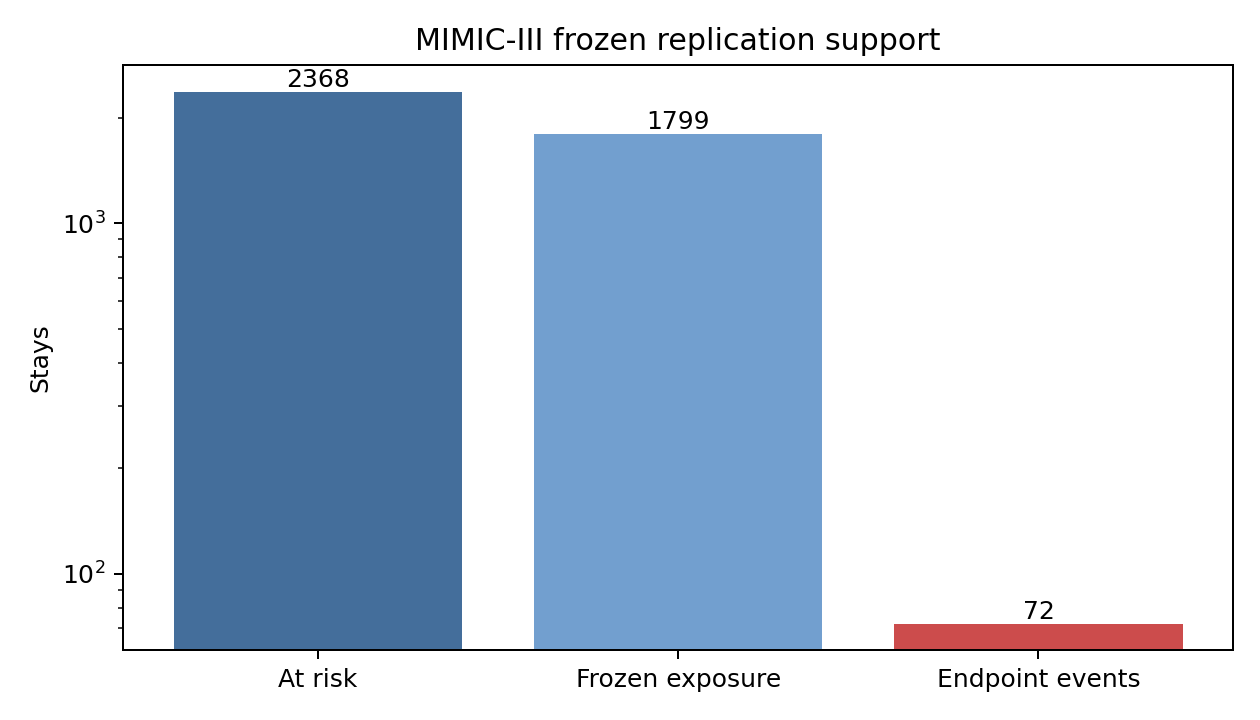

In [4]:
figures = sorted((OUT/'figures').glob('*.png'))
for figure in figures:
    display(Image(filename=str(figure)))

## Interpretation

The endpoint is the frozen constructed pressure/support-plus-hypoperfusion composite, not adjudicated cardiogenic shock. The earlier exposure-coverage and site-count waivers are disclosed. No alternate feature, endpoint, threshold, subgroup, unit, or time-window rescue was used. This result does not change the frozen eICU classification and cannot establish independent external transportability because the MIMIC versions share a source institution.